In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

In [29]:
df = pd.read_csv('data/n90pol.csv')
amygdala = df['amygdala']
acc = df['acc']

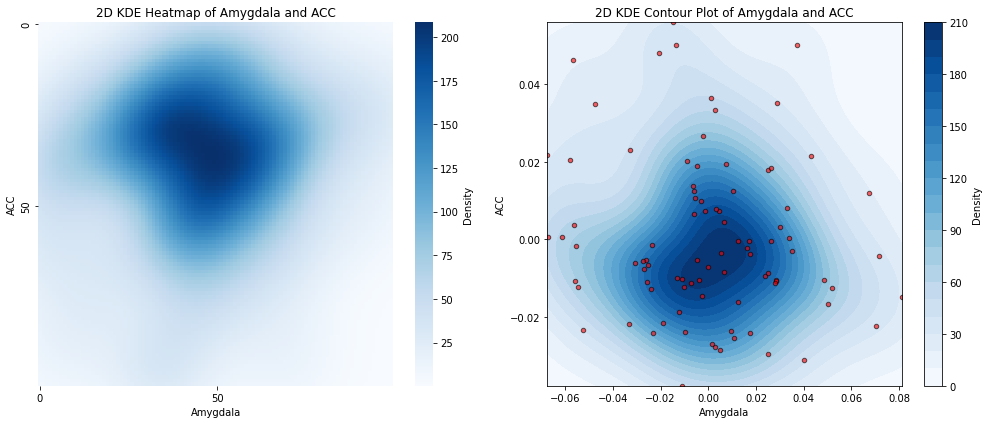

In [30]:
#combine vars
data = np.vstack([amygdala, acc])

kde = gaussian_kde(data, bw_method=0.5)

#estimating grid of points
x = np.linspace(np.min(amygdala), np.max(amygdala), 100)
y = np.linspace(np.min(acc), np.max(acc), 100)
X, Y = np.meshgrid(x, y)
positions = np.vstack([X.ravel(), Y.ravel()])

Z = kde(positions).reshape(X.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(Z, ax=axes[0], xticklabels=50, yticklabels=50, cmap='Blues', cbar_kws={'label': 'Density'})
axes[0].set_title('2D KDE Heatmap of Amygdala and ACC')
axes[0].set_xlabel('Amygdala')
axes[0].set_ylabel('ACC')

contour = axes[1].contourf(X, Y, Z, 20, cmap='Blues')
fig.colorbar(contour, ax=axes[1], label='Density')
axes[1].set_title('2D KDE Contour Plot of Amygdala and ACC')
axes[1].set_xlabel('Amygdala')
axes[1].set_ylabel('ACC')

#to confirm if there are outliers
axes[1].scatter(amygdala, acc, color='red', s=20, edgecolor='black', alpha=0.6)

plt.tight_layout()
plt.show()
